In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the raw Superstore dataset
file_path = "data/raw/sample_-_superstore.xls"

orders = pd.read_excel(file_path, sheet_name="Orders")

print("Dataset loaded successfully!")
print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

Dataset loaded successfully!
Rows: 10194
Columns: 21


In [5]:
# Display all column names
print("Column names:")
for i, column in enumerate(orders.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. Country/Region
10. City
11. State/Province
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales
19. Quantity
20. Discount
21. Profit


In [6]:
# Check data types of all columns
print("Data types:")
print(orders.dtypes)

Data types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object


In [7]:
# Check for missing values
missing_values = orders.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Total missing values: 0


In [8]:
# Check for duplicate rows
duplicate_rows = orders.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [9]:
# Standardize column names
orders.columns = (
    orders.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

print("Standardized column names:")
print(orders.columns.tolist())

Standardized column names:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country_region', 'city', 'state_province', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [10]:
orders = orders.rename(columns={"sub-category": "sub_category"})

print(orders.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country_region', 'city', 'state_province', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [11]:
# Outlier detection using IQR

numeric_columns = ["sales", "quantity", "discount", "profit"]

for column in numeric_columns:
    Q1 = orders[column].quantile(0.25)
    Q3 = orders[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = orders[
        (orders[column] < lower_bound) |
        (orders[column] > upper_bound)
    ]
    
    print(f"\n{column.upper()}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    


SALES
Q1: 17.22
Q3: 209.5
IQR: 192.28
Lower Bound: -271.20000000000005
Upper Bound: 497.92
Number of outliers: 1183

QUANTITY
Q1: 2.0
Q3: 5.0
IQR: 3.0
Lower Bound: -2.5
Upper Bound: 9.5
Number of outliers: 175

DISCOUNT
Q1: 0.0
Q3: 0.2
IQR: 0.2
Lower Bound: -0.30000000000000004
Upper Bound: 0.5
Number of outliers: 874

PROFIT
Q1: 1.7607999999999997
Q3: 29.297924999999985
IQR: 27.537124999999985
Lower Bound: -39.54488749999997
Upper Bound: 70.60361249999997
Number of outliers: 1913


In [12]:
# Check minimum and maximum values
print("Sales range:", orders["sales"].min(), "to", orders["sales"].max())
print("Quantity range:", orders["quantity"].min(), "to", orders["quantity"].max())
print("Discount range:", orders["discount"].min(), "to", orders["discount"].max())
print("Profit range:", orders["profit"].min(), "to", orders["profit"].max())

Sales range: 0.44399999999999995 to 22638.48
Quantity range: 1 to 14
Discount range: 0.0 to 0.8
Profit range: -6599.978000000001 to 8399.975999999999


In [13]:
# Save the cleaned dataset

cleaned_orders = orders.copy()

output_path = "data/processed/superstore_cleaned.csv"

cleaned_orders.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("Rows:", cleaned_orders.shape[0])
print("Columns:", cleaned_orders.shape[1])
print("Saved to:", output_path)

Cleaned dataset saved successfully!
Rows: 10194
Columns: 21
Saved to: data/processed/superstore_cleaned.csv


In [14]:
# Cleaning log

cleaning_log = {
    "Step": [
        "Missing value check",
        "Duplicate check",
        "Column name standardization",
        "Data type verification",
        "Outlier detection"
    ],
    "Action": [
        "Checked all columns for missing values",
        "Checked for duplicate rows",
        "Converted column names to lowercase with underscores",
        "Verified data types for dates, numerical and categorical columns",
        "Detected outliers using the IQR method"
    ],
    "Result": [
        "No missing values found",
        "No duplicate rows found",
        "Column names standardized",
        "Data types are appropriate",
        "Outliers detected and retained as potentially valid business transactions"
    ]
}

cleaning_log_df = pd.DataFrame(cleaning_log)

cleaning_log_df

,Step,Action,Result
0,Missing value check,Checked all columns for missing values,No missing values found
1,Duplicate check,Checked for duplicate rows,No duplicate rows found
2,Column name standardization,Converted column names to lowercase with under...,Column names standardized
3,Data type verification,"Verified data types for dates, numerical and c...",Data types are appropriate
4,Outlier detection,Detected outliers using the IQR method,Outliers detected and retained as potentially ...


In [15]:
# Statistical summary of numerical columns

summary = orders.describe()

summary

,row_id,order_date,ship_date,sales,quantity,discount,profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


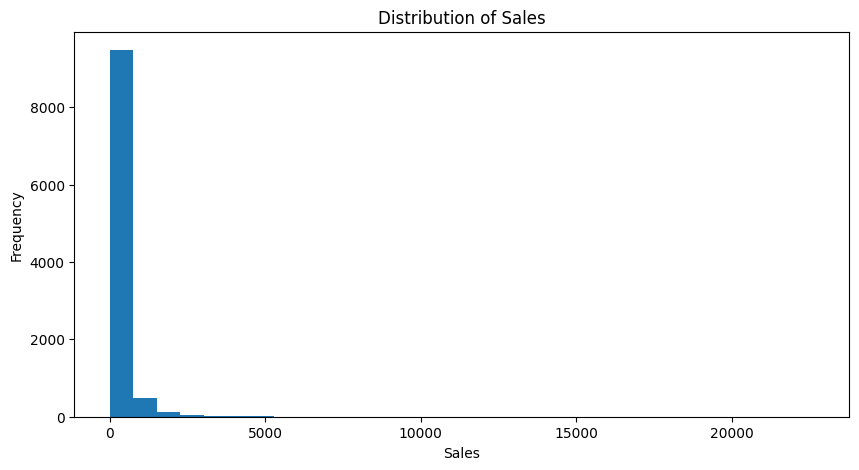

In [16]:
# Histogram of Sales

plt.figure(figsize=(10, 5))

plt.hist(orders["sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Finding: The sales distribution is strongly right-skewed. Most orders have relatively low sales values, while a smaller number of orders have substantially higher sales. The mean sales value (228.23) is considerably higher than the median (53.91), which is consistent with the presence of high-value transactions.

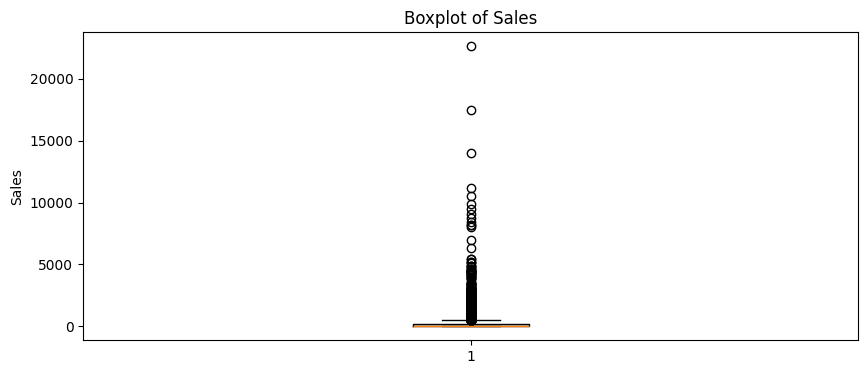

In [21]:
# Boxplot of Sales

plt.figure(figsize=(10, 4))

plt.boxplot(orders["sales"])

plt.title("Boxplot of Sales")
plt.ylabel("Sales")

plt.show()

Finding: The sales boxplot shows a large number of observations above the upper whisker, indicating the presence of statistical outliers. These high-value sales transactions were retained because they may represent legitimate business transactions rather than data-entry errors.

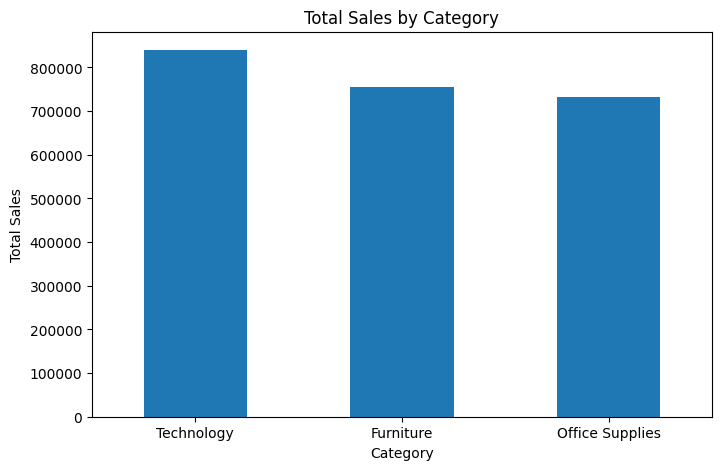

In [18]:
# Sales by Category

category_sales = orders.groupby("category")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

Finding: Technology records the highest total sales among the three product categories, followed by Furniture and Office Supplies. All three categories contribute substantially to overall sales, with Technology showing the largest total.

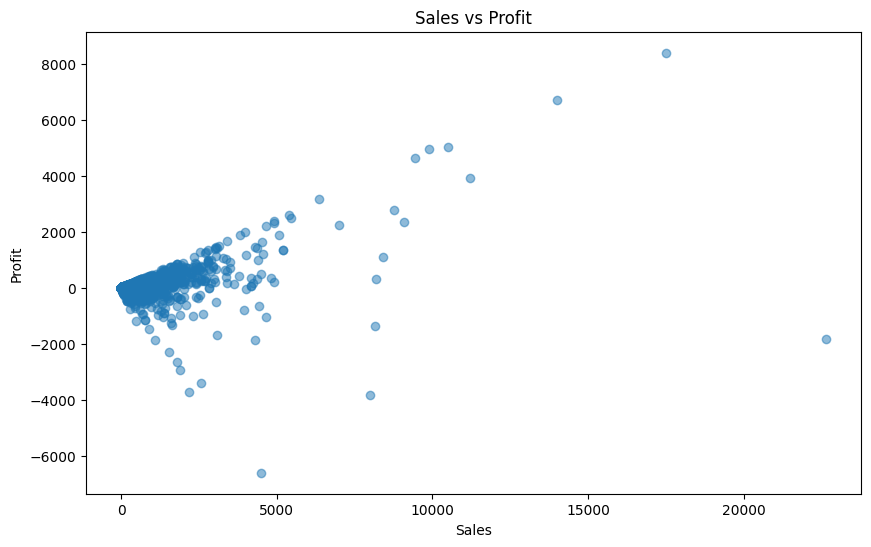

In [22]:
# Sales vs Profit

plt.figure(figsize=(10, 6))

plt.scatter(
    orders["sales"],
    orders["profit"],
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

Finding: The scatter plot shows a generally positive relationship between sales and profit. Most transactions are concentrated at lower sales and profit values, while higher-sales transactions tend to show higher profits. However, some high-sales transactions also result in substantial losses, indicating that higher sales do not always guarantee higher profitability.

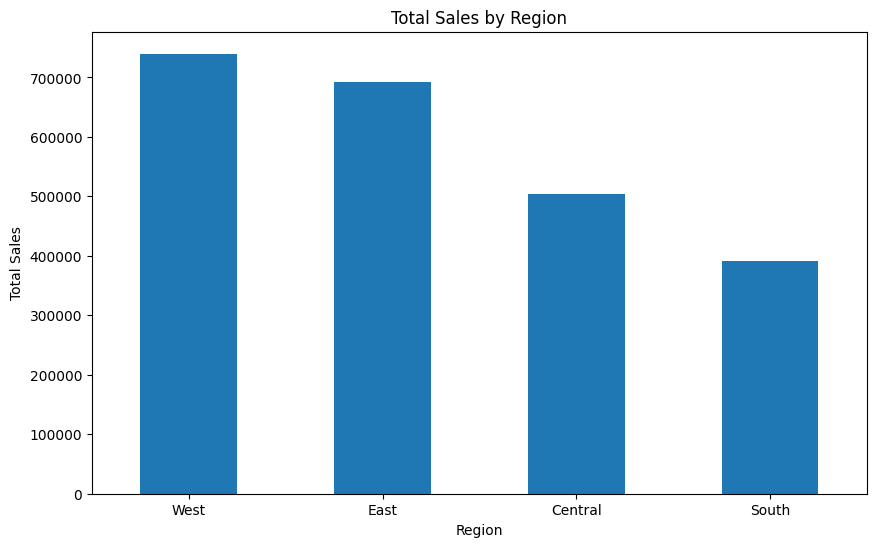

In [23]:
# Total Sales by Region

region_sales = orders.groupby("region")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()


Finding: The West region records the highest total sales, followed by the East, Central, and South regions. The results show noticeable variation in sales performance across the four regions, with the West contributing the largest share of total sales.


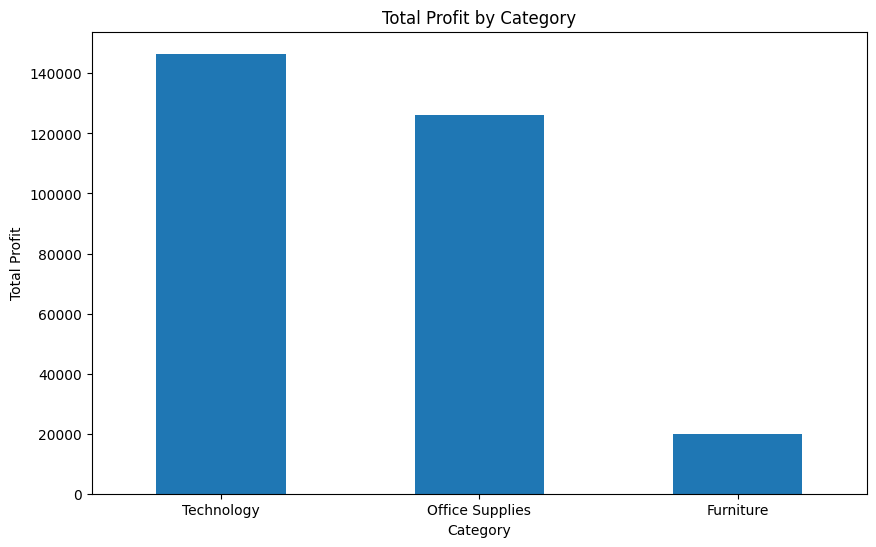

In [24]:
# Total Profit by Category

category_profit = orders.groupby("category")["profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.show()

Finding: Technology generates the highest total profit, followed by Office Supplies, while Furniture records the lowest total profit among the three categories. The results show that sales contribution and profit contribution can differ considerably across product categories.


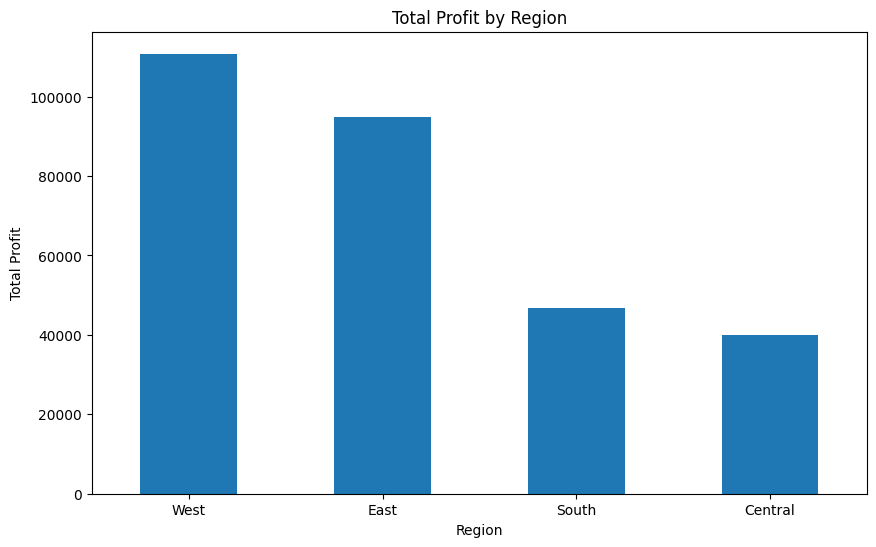

In [25]:
# Total Profit by Region

region_profit = orders.groupby("region")["profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

region_profit.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.show()

Finding: The West region records the highest total profit, followed by the East, South, and Central regions. The results indicate noticeable differences in total profitability across regions, with the West contributing the largest total profit.

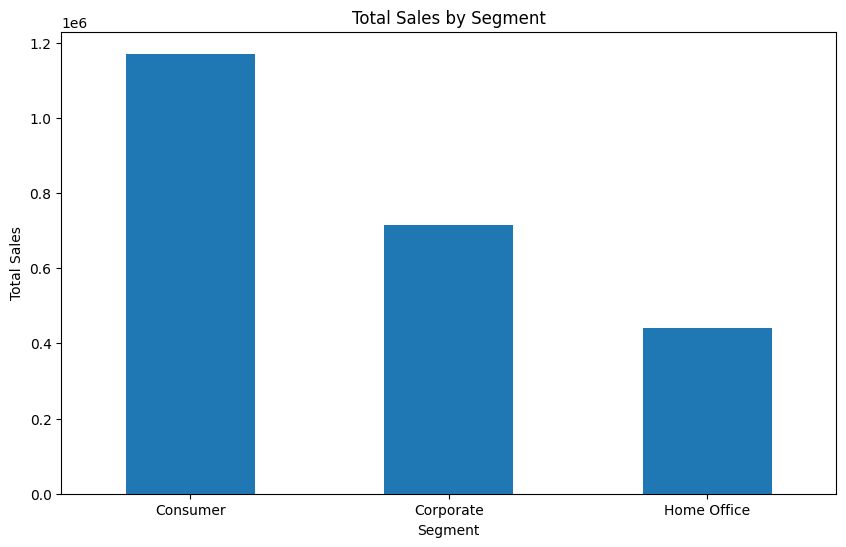

In [26]:
# Total Sales by Segment

segment_sales = orders.groupby("segment")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()



Finding: The Consumer segment records the highest total sales, followed by the Corporate segment, while the Home Office segment has the lowest total sales. This shows that the Consumer segment contributes the largest share of sales among the three customer segments.

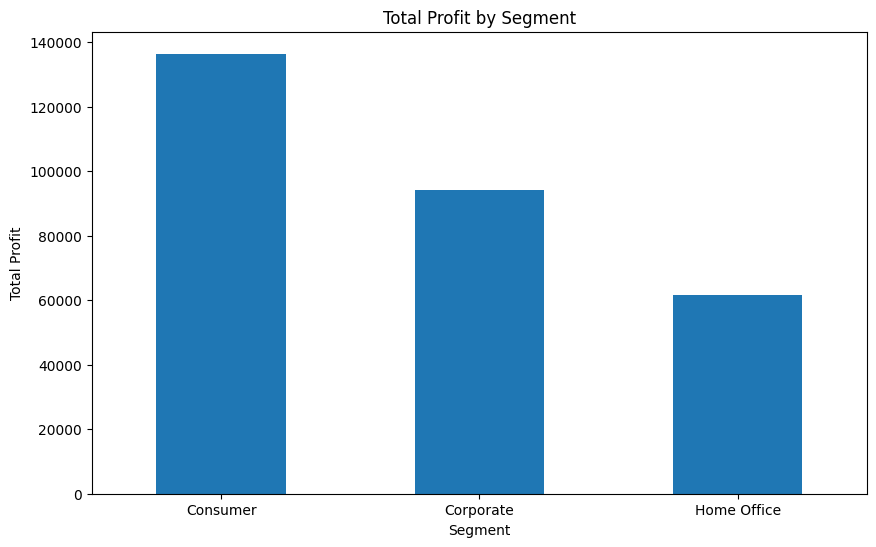

In [27]:
# Total Profit by Segment

segment_profit = orders.groupby("segment")["profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

segment_profit.plot(kind="bar")

plt.title("Total Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.show()

Finding: The Consumer segment records the highest total profit, followed by the Corporate segment, while the Home Office segment records the lowest total profit. The results show that the Consumer segment contributes the largest share of both total sales and total profit.

## Key EDA Insights

- The sales distribution is strongly right-skewed, with most transactions having relatively low sales values and a smaller number of high-value transactions.
- Statistical outliers were identified in sales, quantity, discount, and profit using the IQR method. These observations were retained because they may represent legitimate business transactions.
- Technology records the highest total sales and total profit among the three product categories.
- The West region records the highest total sales and total profit among the four regions.
- The Consumer segment contributes the highest total sales and total profit among the three customer segments.
- The Sales vs Profit scatter plot shows a generally positive relationship, although some high-sales transactions also result in losses.
- Overall, the analysis shows differences in sales and profitability across categories, regions, and customer segments.

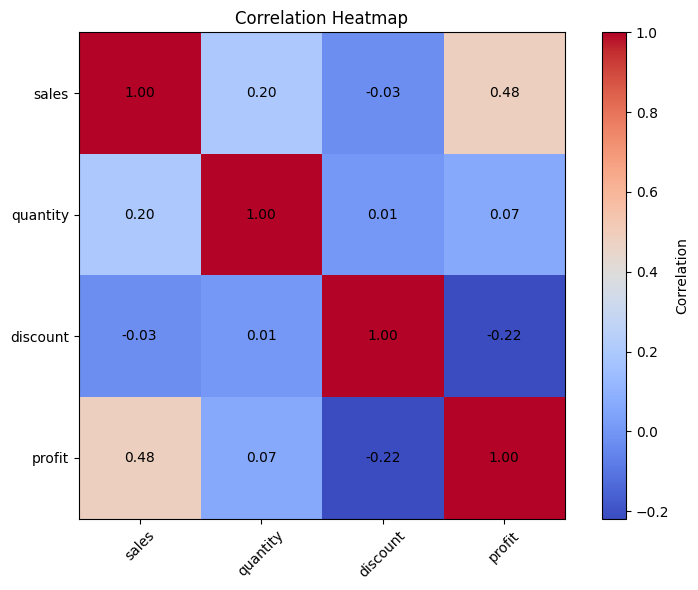

In [28]:
# Correlation Heatmap

import matplotlib.pyplot as plt

# Select important numerical variables
corr = orders[["sales", "quantity", "discount", "profit"]].corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

Finding: The correlation heatmap shows a moderate positive relationship between sales and profit (0.48). Sales and quantity have a weak positive correlation (0.20), while discount and profit show a weak negative correlation (-0.22). The results indicate that these variables have different levels of association, with sales showing the strongest relationship with profit among the variables analyzed.

In [29]:
# Save cleaned dataset

import os

os.makedirs("data/processed", exist_ok=True)

orders.to_csv(
    "data/processed/superstore_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("File: data/processed/superstore_cleaned.csv")

Cleaned dataset saved successfully.
File: data/processed/superstore_cleaned.csv


In [30]:
import os

print(os.path.exists("data/processed/superstore_cleaned.csv"))

True


# Task 1 – Foundational Setup & Exploratory Data Analysis

## Project
Superstore Sales Data Analysis

## Objective
To clean, explore, and analyze the Superstore dataset using Python and identify important patterns, trends, and anomalies.

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Data Preparation
- Standardized column names
- Checked missing values and duplicates
- Checked data types and dates
- Detected outliers using the IQR method
- Retained legitimate outlier observations
- Saved the cleaned dataset as `data/processed/superstore_cleaned.csv`

## Exploratory Data Analysis
The analysis includes:
- Statistical summary
- Sales distribution analysis
- Boxplot analysis
- Sales by category
- Sales by region
- Profit by category
- Profit by region
- Sales and profit by customer segment
- Sales vs Profit analysis
- Correlation heatmap

## Key Insights
- Sales are strongly right-skewed.
- Technology records the highest total sales and profit among the categories.
- The West region records the highest total sales and profit.
- The Consumer segment records the highest total sales and profit.
- Sales and profit show a moderate positive correlation.
- Discount and profit show a weak negative correlation.

## Files
- `task1_eda.ipynb` – Jupyter notebook containing the complete analysis
- `data/processed/superstore_cleaned.csv` – cleaned dataset
- `README.md` – project documentation